### Spectral clustering on the Duffing oscillator (non-autonomous case)

In [1]:
import sys

sys.path.append("..")
import numpy as np

from src import (
    SpectralClusteringConfig,
    calculate_eigenvalues,
    calculate_num_clusters_and_max_eigengap,
    calculate_spectral_indicators,
    compute_weight_matrix,
    find_clusters,
    find_local_maxima,
    generate_initial_conditions,
    ode_non_autonomous_duffing,
    plot_clusters,
    plot_clusters_local_maxs,
    plot_eigengaps_vs_index,
    plot_eigengaps_vs_sparsity,
    plot_eigenvalues_vs_index,
    simulate_trajectories,
    sparsify,
)

np.set_printoptions(precision=3, suppress=True)
%load_ext autoreload
%autoreload 2

In [2]:
params = SpectralClusteringConfig(
    num_dimensions=2,
    t_span=(0, 4 * np.pi),
    t_steps=300,
    x_min=-2,
    x_max=2,
    y_min=-1,
    y_max=1,
    grid_spacing=0.04,
    max_clusters=50,
    num_radii=50,
)

In [3]:
initial_conditions = generate_initial_conditions(params)
trajectories = simulate_trajectories(
    ode_non_autonomous_duffing, initial_conditions, params
)
print("(Num trajectories, t_steps, num_dimension) =", trajectories.shape)

(Num trajectories, t_steps, num_dimension) = (5151, 300, 2)


In [4]:
weight_matrix = compute_weight_matrix(trajectories)

In [5]:
max_weight = np.max(weight_matrix)
print(f"Maximum weight in weight matrix: {max_weight:.3f}")
default_diagonal_constant = max_weight * 1e7

Maximum weight in weight matrix: 159.460


Sparsification of 90% achieved using 1.191 as the sparsification radius.
similarity_matrix =
 [[1.595e+09 2.355e+00 0.000e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [2.355e+00 1.595e+09 1.692e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 1.692e+00 1.595e+09 ... 0.000e+00 0.000e+00 0.000e+00]
 ...
 [0.000e+00 0.000e+00 0.000e+00 ... 1.595e+09 4.838e+00 2.580e+00]
 [0.000e+00 0.000e+00 0.000e+00 ... 4.838e+00 1.595e+09 5.437e+00]
 [0.000e+00 0.000e+00 0.000e+00 ... 2.580e+00 5.437e+00 1.595e+09]]
eigvectors.shape = (5151, 50)
50 eigvals = [-3.3e-19 9.0e-10 2.7e-09 3.0e-09 4.0e-09 4.6e-09 6.8e-09 7.8e-09 1.1e-08
 1.2e-08 1.7e-08 2.0e-08 2.0e-08 2.2e-08 2.5e-08 2.7e-08 2.9e-08 3.0e-08
 3.1e-08 3.2e-08 3.2e-08 3.3e-08 3.4e-08 3.5e-08 3.5e-08 3.6e-08 3.7e-08
 3.7e-08 3.8e-08 3.8e-08 3.8e-08 4.0e-08 4.1e-08 4.1e-08 4.1e-08 4.2e-08
 4.3e-08 4.4e-08 4.5e-08 4.5e-08 4.5e-08 4.6e-08 4.7e-08 4.7e-08 4.7e-08
 4.8e-08 4.9e-08 4.9e-08 4.9e-08 5.0e-08]


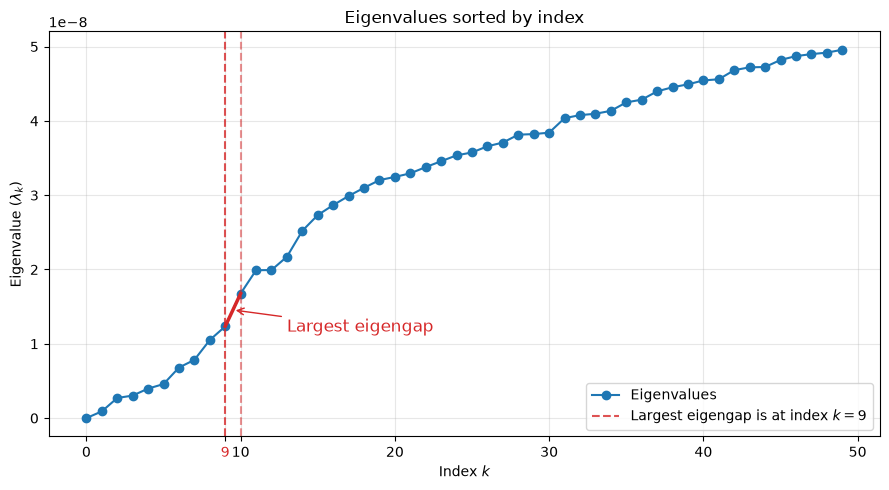

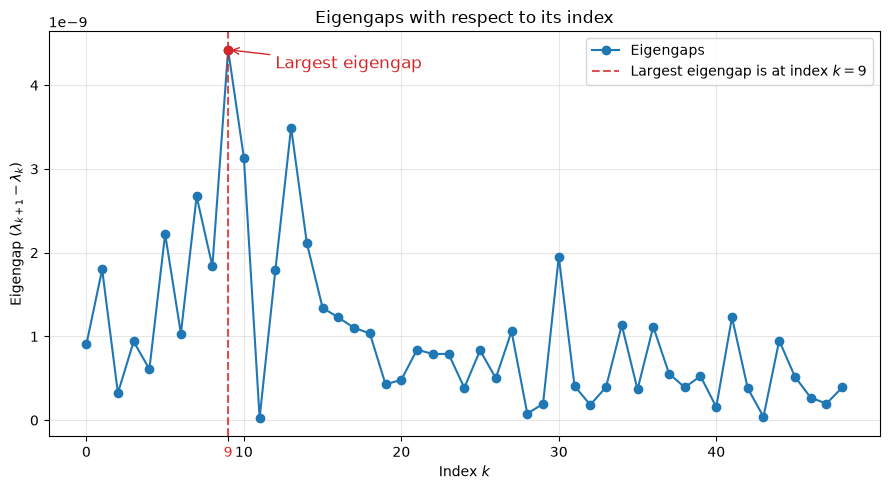

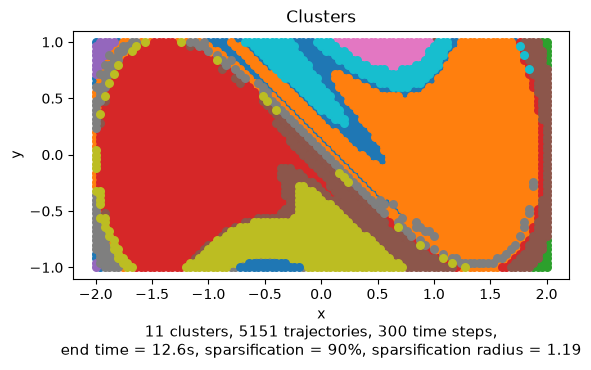

In [6]:
# Option A: esparsify at 90%
similarity_matrix, sparsification_radius, sparsification_percent = sparsify(
    weight_matrix, sparsification_percent=90
)
print(
    f"Sparsification of {sparsification_percent * 100:.0f}% achieved "
    f"using {sparsification_radius:.3f} as the sparsification radius."
)
np.fill_diagonal(similarity_matrix, default_diagonal_constant)
print("similarity_matrix =\n", similarity_matrix)
eigvals, eigvectors = calculate_eigenvalues(similarity_matrix, params.max_clusters)
print("eigvectors.shape =", eigvectors.shape)
print(
    len(eigvals),
    "eigvals =",
    np.array2string(eigvals, formatter={"float_kind": lambda x: f"{x:.1e}"}),
)
plot_eigenvalues_vs_index(eigvals, subfolder="non_autonomous")
plot_eigengaps_vs_index(eigvals, subfolder="non_autonomous")
num_clusters, diff_max = calculate_num_clusters_and_max_eigengap(eigvals)
labels = find_clusters(num_clusters, eigvectors)
plot_clusters(
    initial_conditions,
    labels,
    num_clusters,
    sparsification_radius,
    sparsification_percent,
    params,
    subfolder="non_autonomous",
)

In [7]:
# Option B: adaptive method
# Choose the sparsification radii that maximize the largest eigengap
result = calculate_spectral_indicators(weight_matrix, default_diagonal_constant, params)

local_maxs_indices = [2, 9, 26, 31, 34, 36, 47]
radii[local_maxs_indices] = [0.32  0.519 1.002 1.144 1.23  1.287 1.6  ]
Local maximum #1
Sparsification radius: 0.320, Sparsification percent: 0.27%, Clusters: 2, Max eigengap: 1.45384e-06


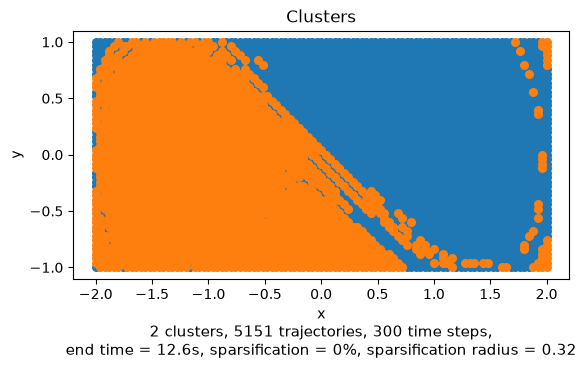

Local maximum #2
Sparsification radius: 0.519, Sparsification percent: 40.81%, Clusters: 2, Max eigengap: 3.34875e-07


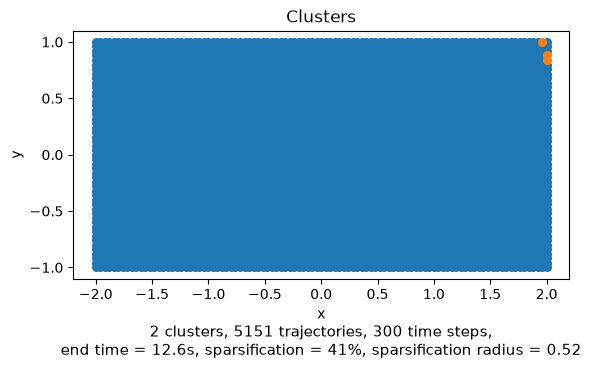

Local maximum #3
Sparsification radius: 1.002, Sparsification percent: 85.34%, Clusters: 10, Max eigengap: 5.86202e-09


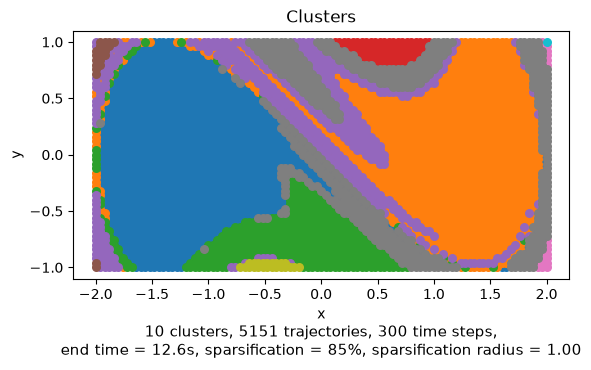

Local maximum #4
Sparsification radius: 1.144, Sparsification percent: 89.09%, Clusters: 11, Max eigengap: 5.24389e-09


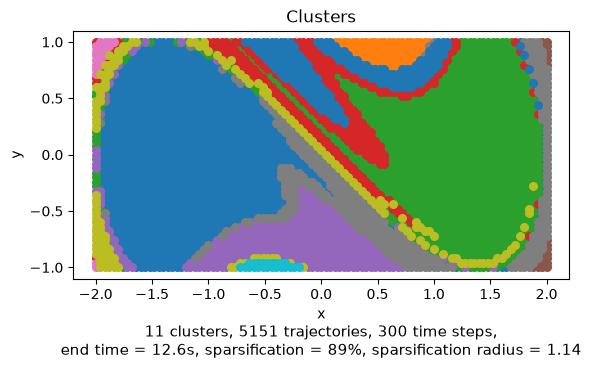

Local maximum #5
Sparsification radius: 1.230, Sparsification percent: 90.68%, Clusters: 15, Max eigengap: 5.86901e-09


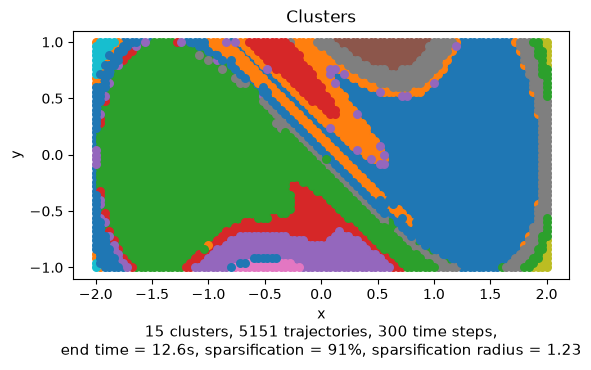

Local maximum #6
Sparsification radius: 1.287, Sparsification percent: 91.54%, Clusters: 15, Max eigengap: 5.35113e-09


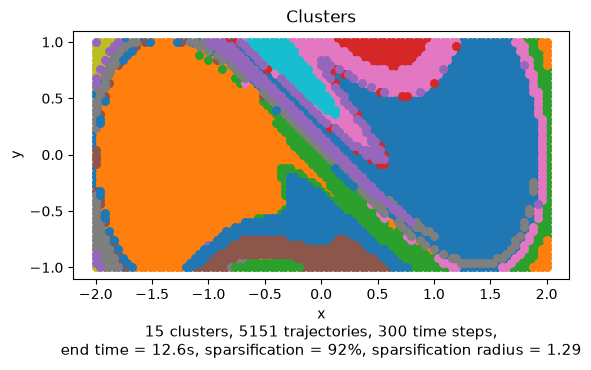

Local maximum #7
Sparsification radius: 1.600, Sparsification percent: 94.63%, Clusters: 36, Max eigengap: 1.30554e-09


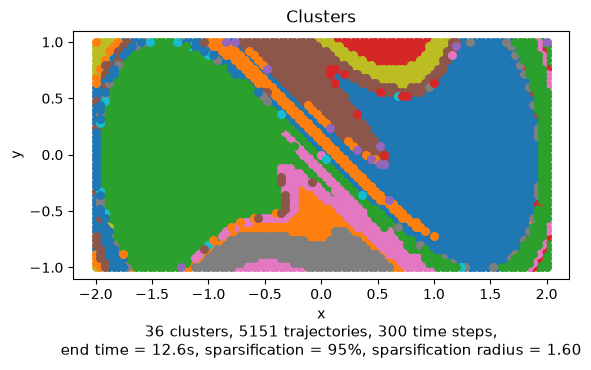

In [8]:
local_maxs_indices = find_local_maxima(result.normalized_eigengaps)
print("local_maxs_indices =", local_maxs_indices)
print("radii[local_maxs_indices] =", result.sparsification_radii[local_maxs_indices])
plot_clusters_local_maxs(
    local_maxs_indices,
    result,
    initial_conditions,
    params,
    subfolder="non_autonomous_local_maxs",
)

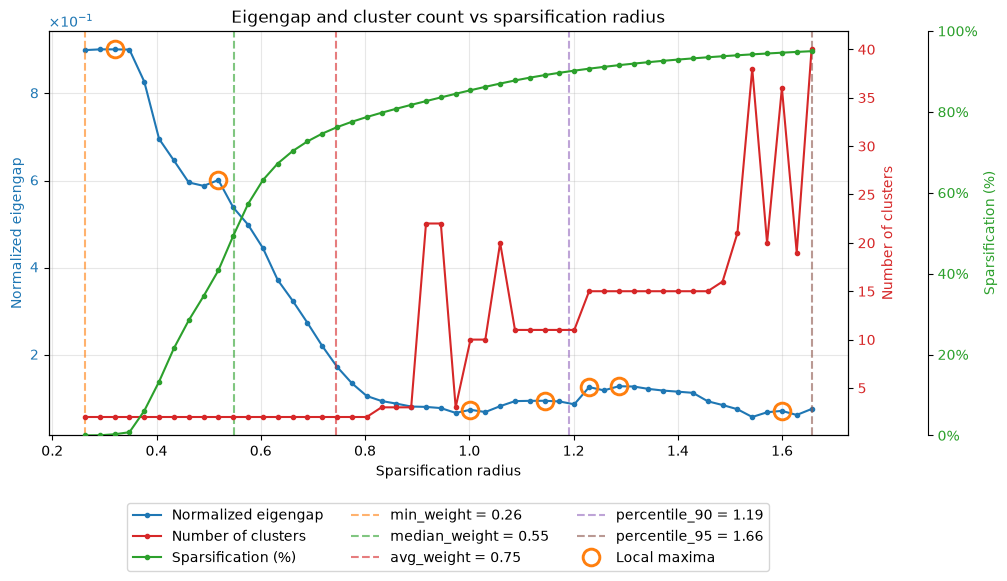

In [9]:
plot_eigengaps_vs_sparsity(
    result,
    params,
    eigengap_local_maxima_indices=local_maxs_indices,
    subfolder="non_autonomous_local_maxs",
)